# 6D-VHQ Analysis Notebook 7: Cross-Experiment Analysis


In [6]:
## libraries

import pandas as pd
from pathlib import Path
import os
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import warnings
import statsmodels.formula.api as smf


In [7]:
### filepaths ###

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")


## Import data from strobe and psychedelic experiments

In [8]:
df_vhq_lab_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_lab_dims.csv"))
display(df_vhq_lab_dims)

df_vhq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_dims.csv"))
display(df_vhq_rec_dims)


,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
0,participant_001,0,1,53BA74C6021,2.000000,1.000000,1.666667,5.000000,1.000000,4.333333
1,participant_001,1,1,53BA74C6021,2.333333,1.000000,1.000000,4.000000,1.333333,5.000000
2,participant_001,2,1,53BA74C6021,2.000000,1.000000,1.000000,5.000000,1.333333,5.000000
3,participant_001,3,1,53BA74C6021,4.000000,1.333333,2.333333,3.666667,3.333333,5.000000
4,participant_001,4,1,53BA74C6021,5.000000,2.000000,4.666667,5.000000,2.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,participant_055,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,participant_055,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,participant_055,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,participant_055,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


,ResponseId,geometric,semantic,detail,vividness,entropy,focality
0,R_2XhSm3rVuTDh2XT,1.333333,5.000000,5.000000,4.333333,1.666667,2.666667
1,R_82J66rTAKMAkEMO,1.666667,2.000000,3.333333,5.000000,1.666667,1.333333
2,R_80OjC1M5y1RxlPM,5.000000,4.333333,2.000000,4.333333,1.666667,3.000000
3,R_8rdBxiZHeShoPvf,5.000000,1.333333,3.333333,3.333333,3.000000,4.000000
4,R_2rH7YSrGIo4VOqn,5.000000,3.666667,5.000000,5.000000,2.333333,3.000000
...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,5.000000,2.333333,5.000000,5.000000,1.000000,1.000000
197,R_1levP6TzI6EFeP7,3.666667,3.666667,4.000000,4.333333,4.333333,1.333333
198,R_6QEuAAP3YqW0Th7,3.666667,2.666667,4.333333,4.000000,1.000000,2.666667
199,R_6rF4jrVpI9mVj9v,3.000000,3.000000,5.000000,5.000000,1.000000,3.666667


## How do VHs differ across context

In [12]:
# ============================================================
# Mixed-effects comparison: lab-induced hallucinations (0–6)
# vs psychedelic hallucinations, with random intercepts for
# participant and Holm correction across the 6 dimensions.
#
# Notes:
# - Lab data: repeated measures within participant (pcode)
# - Psychedelic data: one response per participant (ResponseId)
# - Only lab conditions 0–6 are included here
# - Control / training / other lab conditions are excluded
# - Model is fit by maximum likelihood (reml=False)
# ============================================================

dim_cols = ["geometric", "semantic", "detail", "vividness", "entropy", "focality"]

strobe_mask = df_vhq_lab_dims["condition_num"].between(0, 6, inclusive="both")
control_mask = df_vhq_lab_dims["condition_num"] == 7

# -----------------------------
# Prepare lab data
# -----------------------------
df_vhq_lab_dims = df_vhq_lab_dims.copy()
df_vhq_lab_dims["condition_num"] = pd.to_numeric(df_vhq_lab_dims["condition"], errors="coerce")
lab_mask = df_vhq_lab_dims["condition_num"].between(0, 6, inclusive="both")

lab_use = df_vhq_lab_dims.loc[lab_mask, ["pcode"] + dim_cols].copy()
lab_use["dataset"] = "lab"
lab_use["participant_id"] = "lab_" + lab_use["pcode"].astype(str)

# -----------------------------
# Prepare psychedelic data
# -----------------------------
df_vhq_rec_dims = df_vhq_rec_dims.copy()
psy_use = df_vhq_rec_dims[["ResponseId"] + dim_cols].copy()
psy_use["dataset"] = "psychedelic"
psy_use["participant_id"] = "psy_" + psy_use["ResponseId"].astype(str)

# -----------------------------
# Helpers
# -----------------------------
def sig_stars(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def fmt_p_apa(p):
    """APA-style p formatting."""
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "< .001"
    return f"= {p:.3f}".replace("0.", "." if p < 1 else "0.")

def cohen_d_independent(a, b):
    """
    Cohen's d for independent samples.
    Sign = mean(a) - mean(b).
    Here this is used descriptively on participant-level data:
    lab participant means vs psychedelic single-response participants.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(a, ddof=1)
    s2 = np.var(b, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if s_pooled == 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / s_pooled

def fit_mixedlm_with_fallback(formula, data, groups):
    """
    Fit MixedLM by maximum likelihood with a conservative fallback
    if the default optimiser struggles.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = smf.mixedlm(formula, data=data, groups=groups)
        try:
            result = model.fit(reml=False, method="lbfgs", maxiter=2000, disp=False)
        except Exception:
            result = model.fit(reml=False, method="powell", maxiter=2000, disp=False)
    return result

# ============================================================
# One mixed model per dimension
# outcome ~ dataset, random intercept for participant
# Reference level = lab, so coefficient for dataset[T.psychedelic]
# is psychedelic - lab
# ============================================================

rows = []

for dim in dim_cols:
    # Long dataframe for this dimension
    tmp_lab = lab_use[["participant_id", "dataset", dim]].rename(columns={dim: "outcome"}).copy()
    tmp_psy = psy_use[["participant_id", "dataset", dim]].rename(columns={dim: "outcome"}).copy()

    tmp = pd.concat([tmp_lab, tmp_psy], axis=0, ignore_index=True)
    tmp["outcome"] = pd.to_numeric(tmp["outcome"], errors="coerce")
    tmp = tmp.dropna(subset=["outcome", "participant_id", "dataset"]).copy()

    # Set reference group explicitly: lab first, psychedelic second
    tmp["dataset"] = pd.Categorical(tmp["dataset"], categories=["lab", "psychedelic"], ordered=True)

    if tmp["dataset"].nunique() < 2:
        print(f"Skipping {dim}: one of the groups is empty after cleaning.")
        continue

    # Descriptive statistics at participant level
    lab_participant_means = (
        tmp.loc[tmp["dataset"] == "lab"]
        .groupby("participant_id")["outcome"]
        .mean()
        .astype(float)
    )
    psy_participant_vals = (
        tmp.loc[tmp["dataset"] == "psychedelic"]
        .groupby("participant_id")["outcome"]
        .mean()
        .astype(float)
    )

    # Response counts (for transparency)
    n_lab_participants = lab_participant_means.shape[0]
    n_psy_participants = psy_participant_vals.shape[0]
    n_lab_responses = int((tmp["dataset"] == "lab").sum())
    n_psy_responses = int((tmp["dataset"] == "psychedelic").sum())

    if n_lab_participants < 2 or n_psy_participants < 2:
        print(f"Skipping {dim}: insufficient participant counts after cleaning.")
        continue

    # Fit model
    try:
        result = fit_mixedlm_with_fallback(
            formula="outcome ~ dataset",
            data=tmp,
            groups=tmp["participant_id"]
        )
    except Exception as e:
        print(f"Skipping {dim}: model failed with error: {e}")
        continue

    coef_name = "dataset[T.psychedelic]"
    if coef_name not in result.params.index:
        print(f"Skipping {dim}: expected coefficient {coef_name} not found.")
        continue

    beta = float(result.params[coef_name])                 # psychedelic - lab
    se = float(result.bse[coef_name])
    z_val = float(result.tvalues[coef_name])               # MixedLM reports Wald z here
    p_val = float(result.pvalues[coef_name])

    # Descriptive means/SDs at participant level
    mean_lab = float(lab_participant_means.mean())
    sd_lab = float(lab_participant_means.std(ddof=1))
    mean_psy = float(psy_participant_vals.mean())
    sd_psy = float(psy_participant_vals.std(ddof=1))

    # Descriptive effect size at participant level
    d_lab_minus_psy = cohen_d_independent(lab_participant_means.values, psy_participant_vals.values)

    rows.append({
        "test": "Mixed model: lab vs psychedelic",
        "dimension": dim,
        "group1": "lab hallucinations (conditions 0–6)",
        "group2": "psychedelic",
        "n_group1": n_lab_participants,             # participants
        "n_group2": n_psy_participants,             # participants
        "n_group1_responses": n_lab_responses,      # repeated rows in lab
        "n_group2_responses": n_psy_responses,      # usually same as participants
        "mean_group1": mean_lab,
        "sd_group1": sd_lab,
        "mean_group2": mean_psy,
        "sd_group2": sd_psy,
        "mean_diff_g2_minus_g1": mean_psy - mean_lab,   # descriptive participant-level difference
        "beta_g2_minus_g1": beta,                       # model coefficient: psychedelic - lab
        "se": se,
        "z": z_val,
        "p": p_val,                                    # raw p; adjusted below
        "cohen_d": d_lab_minus_psy,                    # sign = lab - psychedelic
        "sig": sig_stars(p_val),
    })

mixed_results = pd.DataFrame(rows)

# -----------------------------
# Holm correction across the 6 dimensions
# -----------------------------
mixed_results["p_raw"] = mixed_results["p"].astype(float)
mixed_results["p_adj_holm"] = multipletests(
    mixed_results["p_raw"].values,
    alpha=0.05,
    method="holm"
)[1]

# Update significance and downstream p column
mixed_results["sig"] = mixed_results["p_adj_holm"].apply(sig_stars)
mixed_results["p"] = mixed_results["p_adj_holm"]

# -----------------------------
# Final column order / rounding
# -----------------------------
col_order = [
    "test", "dimension",
    "p_raw", "p_adj_holm", "p",
    "group1", "group2",
    "n_group1", "n_group2",
    "n_group1_responses", "n_group2_responses",
    "mean_group1", "sd_group1",
    "mean_group2", "sd_group2",
    "mean_diff_g2_minus_g1",
    "beta_g2_minus_g1", "se", "z", "cohen_d", "sig"
]
mixed_results = mixed_results[col_order]

for c in [
    "p_raw", "p_adj_holm", "p",
    "mean_group1", "sd_group1",
    "mean_group2", "sd_group2",
    "mean_diff_g2_minus_g1",
    "beta_g2_minus_g1", "se", "z", "cohen_d"
]:
    mixed_results[c] = mixed_results[c].astype(float).round(3)

print("\nSupplementary table (mixed-effects models; ML fit; Holm correction across 6 dimensions):\n")
print(mixed_results)

# ============================================================
# APA-style printed output
# ============================================================
print("\nAPA-style mixed-model results (Holm-adjusted across 6 dimensions):\n")
for _, row in mixed_results.iterrows():
    dim = row["dimension"]
    z_ = row["z"]
    beta_ = row["beta_g2_minus_g1"]   # psychedelic - lab
    se_ = row["se"]
    p_ = row["p"]                     # adjusted p
    d_ = row["cohen_d"]               # lab - psychedelic (descriptive)
    p_txt = fmt_p_apa(p_)

    m_lab, sd_lab = row["mean_group1"], row["sd_group1"]
    m_psy, sd_psy = row["mean_group2"], row["sd_group2"]
    n_lab = int(row["n_group1"])
    n_psy = int(row["n_group2"])
    nr_lab = int(row["n_group1_responses"])
    nr_psy = int(row["n_group2_responses"])

    print(
        f"{dim}: β = {beta_:.2f}, SE = {se_:.2f}, z = {z_:.2f}, p {p_txt}, "
        f"d = {d_:.2f}, "
        f"M_lab = {m_lab:.2f}, SD_lab = {sd_lab:.2f} (participants = {n_lab}, responses = {nr_lab}); "
        f"M_psychedelic = {m_psy:.2f}, SD_psychedelic = {sd_psy:.2f} "
        f"(participants = {n_psy}, responses = {nr_psy})."
    )

def apa_entry(dim, beta_, se_, z_, p_, d_):
    """Return 'geometric, β = 0.42, SE = 0.09, z = 4.66, p < .001, d = -0.81'."""
    p_txt = fmt_p_apa(p_)
    return f"{dim}, β = {beta_:.2f}, SE = {se_:.2f}, z = {z_:.2f}, p {p_txt}, d = {d_:.2f}"

block_entries = []
for _, row in mixed_results.iterrows():
    entry = apa_entry(
        dim=row["dimension"],
        beta_=row["beta_g2_minus_g1"],   # psychedelic - lab
        se_=row["se"],
        z_=row["z"],
        p_=row["p"],                     # adjusted p
        d_=row["cohen_d"]                # lab - psychedelic
    )
    block_entries.append(entry)

block_text = "(" + "; ".join(block_entries) + ")."

print("\n==============================")
print("Lab vs psychedelic APA reporting")
print("==============================")
print(block_text)

display(mixed_results)


Supplementary table (mixed-effects models; ML fit; Holm correction across 6 dimensions):

                              test  dimension  p_raw  p_adj_holm      p  \
0  Mixed model: lab vs psychedelic  geometric    0.0       0.001  0.001   
1  Mixed model: lab vs psychedelic   semantic    0.0       0.000  0.000   
2  Mixed model: lab vs psychedelic     detail    0.0       0.000  0.000   
3  Mixed model: lab vs psychedelic  vividness    0.1       0.100  0.100   
4  Mixed model: lab vs psychedelic    entropy    0.0       0.001  0.001   
5  Mixed model: lab vs psychedelic   focality    0.0       0.001  0.001   

                                group1       group2  n_group1  n_group2  \
0  lab hallucinations (conditions 0–6)  psychedelic        55       201   
1  lab hallucinations (conditions 0–6)  psychedelic        55       201   
2  lab hallucinations (conditions 0–6)  psychedelic        55       201   
3  lab hallucinations (conditions 0–6)  psychedelic        55       201   
4  lab h

,test,dimension,p_raw,p_adj_holm,p,group1,group2,n_group1,n_group2,n_group1_responses,...,mean_group1,sd_group1,mean_group2,sd_group2,mean_diff_g2_minus_g1,beta_g2_minus_g1,se,z,cohen_d,sig
0,Mixed model: lab vs psychedelic,geometric,0.0,0.001,0.001,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,3.729,0.626,4.164,1.180,0.435,0.435,0.119,3.648,-0.401,**
1,Mixed model: lab vs psychedelic,semantic,0.0,0.000,0.000,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,1.522,0.617,2.703,1.225,1.181,1.181,0.142,8.308,-1.051,***
2,Mixed model: lab vs psychedelic,detail,0.0,0.000,0.000,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,2.577,0.875,3.803,1.181,1.226,1.226,0.139,8.792,-1.092,***
3,Mixed model: lab vs psychedelic,vividness,0.1,0.100,0.100,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,3.882,0.824,4.096,1.034,0.214,0.214,0.130,1.646,-0.215,ns
4,Mixed model: lab vs psychedelic,entropy,0.0,0.001,0.001,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,2.982,0.847,2.493,1.119,-0.489,-0.489,0.134,-3.644,0.459,**
5,Mixed model: lab vs psychedelic,focality,0.0,0.001,0.001,lab hallucinations (conditions 0–6),psychedelic,55,201,385,...,2.900,0.773,2.444,1.099,-0.455,-0.455,0.127,-3.575,0.438,**


In [13]:
# ==========================================================
# Descriptive table: Mean (SD) by group × 6D-VHQ dimension
# ==========================================================

group_defs = {
    "psychedelic": df_vhq_rec_dims,
    "strobe (0–6)": df_vhq_lab_dims.loc[strobe_mask],
    "control (7)": df_vhq_lab_dims.loc[control_mask],
    "hallucinations (strobe+psy)": None,  # will be constructed per-dimension
}

desc_rows = []
for dim in dim_cols:
    # Build hallucinations vector for this dimension (strobe+psy)
    psy = df_vhq_rec_dims[dim].astype(float)
    strobe = df_vhq_lab_dims.loc[strobe_mask, dim].astype(float)
    control = df_vhq_lab_dims.loc[control_mask, dim].astype(float)
    halluc = pd.concat([strobe, psy], axis=0)

    series_map = {
        "psychedelic": psy,
        "strobe (0–6)": strobe,
        "control (7)": control,
        "hallucinations (strobe+psy)": halluc,
    }

    for group_name, s in series_map.items():
        s = pd.to_numeric(s, errors="coerce").dropna()
        desc_rows.append({
            "dimension": dim,
            "group": group_name,
            "n": int(s.shape[0]),
            "mean": float(s.mean()) if len(s) else np.nan,
            "sd": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        })

desc_long = pd.DataFrame(desc_rows)

# Wide table: one row per dimension, columns per group
desc_wide = (
    desc_long
    .assign(mean_sd=lambda d: d.apply(lambda r: f"{r['mean']:.2f} ({r['sd']:.2f})" if pd.notna(r["mean"]) else "n/a", axis=1))
    .pivot(index="dimension", columns="group", values="mean_sd")
)

# Also provide n per group (optional but useful)
n_wide = desc_long.pivot(index="dimension", columns="group", values="n").astype("Int64")

# Order groups consistently
group_order = ["psychedelic", "strobe (0–6)", "control (7)", "hallucinations (strobe+psy)"]
desc_wide = desc_wide.reindex(columns=group_order)
n_wide = n_wide.reindex(columns=group_order)


print("\nDescriptives: Mean (SD) by group × dimension\n")
display(desc_wide)



Descriptives: Mean (SD) by group × dimension



group,psychedelic,strobe (0–6),control (7),hallucinations (strobe+psy)
dimension,,,,
detail,3.80 (1.18),2.58 (1.32),1.24 (0.61),3.00 (1.40)
entropy,2.49 (1.12),2.98 (1.37),1.42 (0.75),2.81 (1.31)
focality,2.44 (1.10),2.90 (1.32),2.33 (1.31),2.74 (1.27)
geometric,4.16 (1.18),3.73 (1.30),1.29 (0.57),3.88 (1.28)
semantic,2.70 (1.22),1.52 (0.89),1.61 (0.70),1.93 (1.16)
vividness,4.10 (1.03),3.88 (1.07),3.56 (1.25),3.96 (1.06)


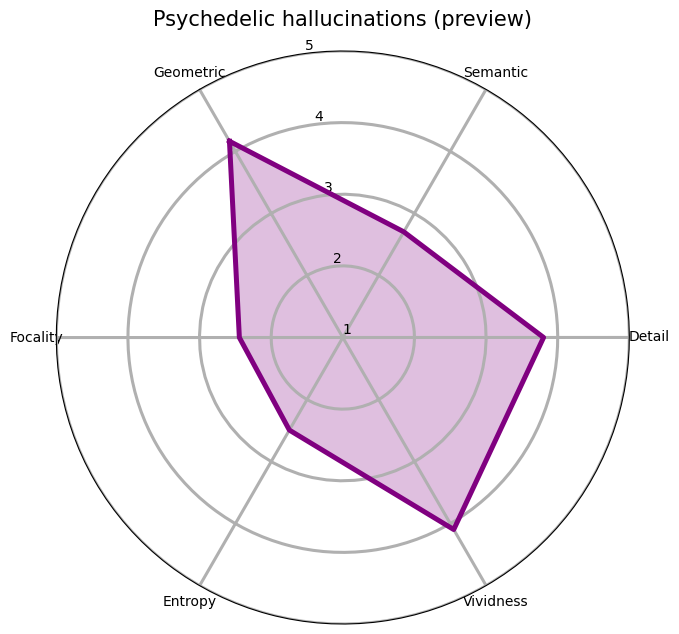

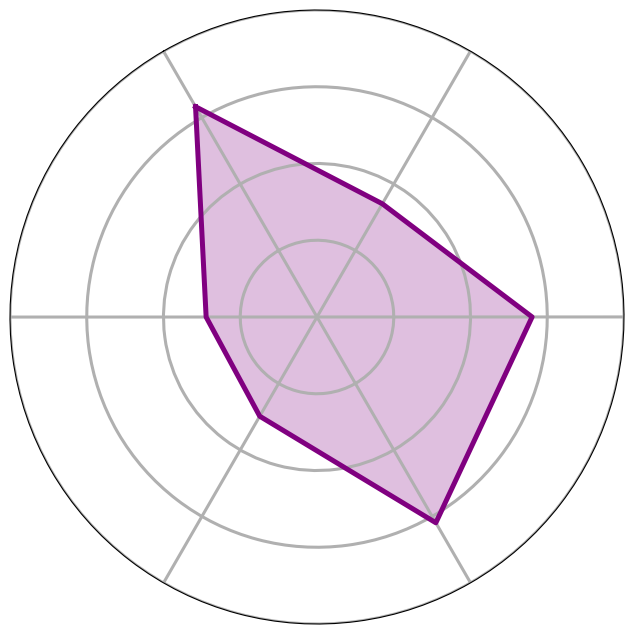

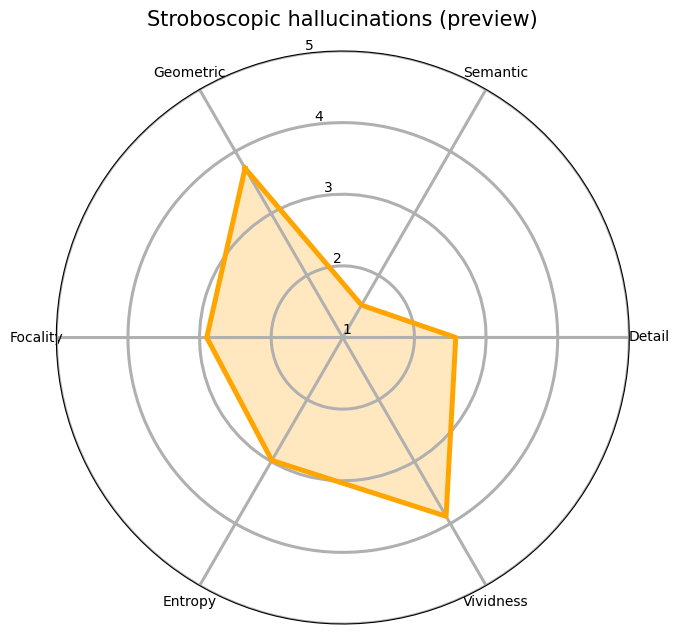

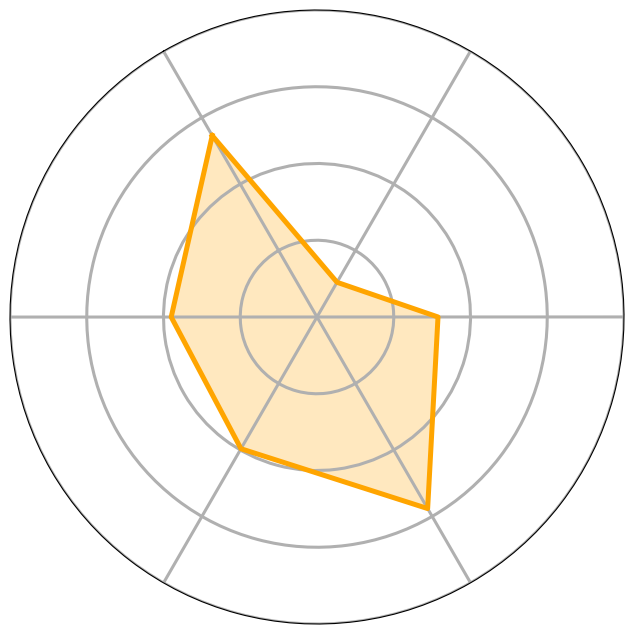

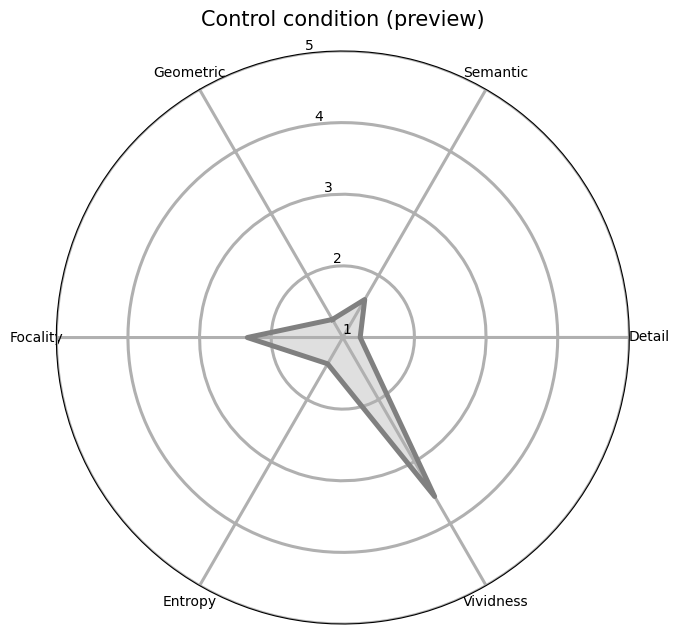

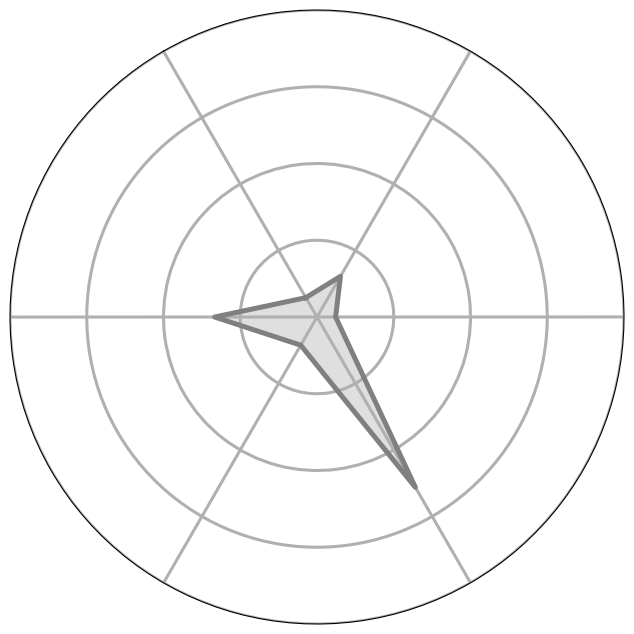

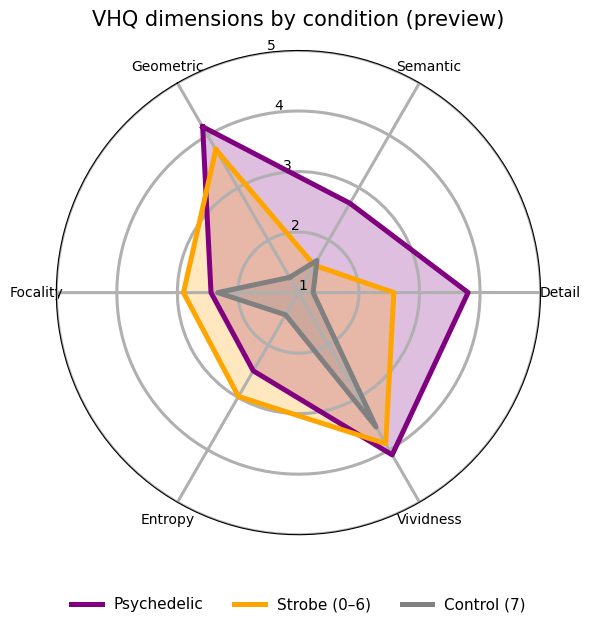

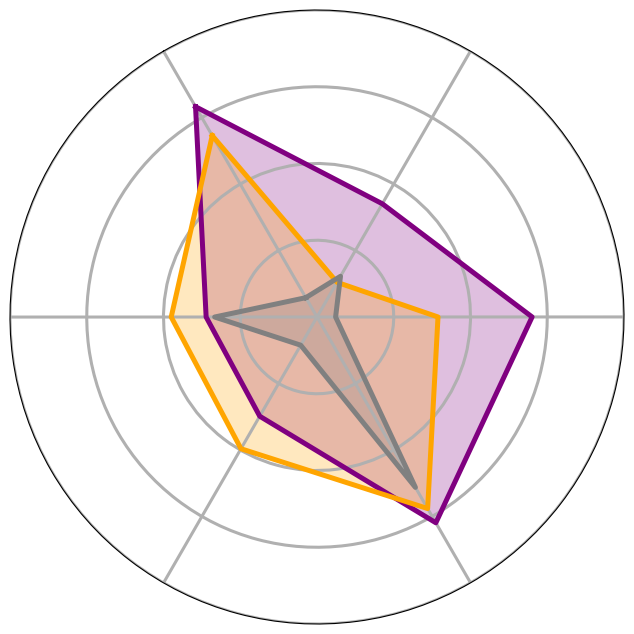

In [15]:


### globals

fig_width  = 12      # or your previous value
fig_height = 14      # or your previous value

spider_rot = np.deg2rad(30.01)   # your earlier rotation
lw_line    = 2                   # base linewidth multiplier
alpha_fill = 0.25                # transparency
text_size  = 14                  # legend text size baselin

# ============================================
# 1. Dimensions & angles
# ============================================
dims = ["geometric", "semantic", "detail", "vividness", "entropy", "focality"]
n_dims = len(dims)

angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]  # close the loop

radial_ticks = [1, 2, 3, 4, 5]

# Colours for conditions
color_psy     = "purple"
color_strobe  = "orange"
color_control = "grey"

# ============================================
# 2. Mean profiles (pooled, trial-level)
# ============================================
psy_profile = df_vhq_rec_dims[dims].astype(float).mean().values

strobe_profile = (
    df_vhq_lab_dims
    .loc[strobe_mask, dims]
    .astype(float)
    .mean()
    .values
)

control_profile = (
    df_vhq_lab_dims
    .loc[control_mask, dims]
    .astype(float)
    .mean()
    .values
)

# ============================================
# 3. Generic radar helper with preview/real mode
# ============================================
def make_radar_figure_conditions(
    profiles,
    labels,
    colors,
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=True,
    legend_ncol=1
):
    """
    profiles: list of 1D arrays/lists with length = n_dims
    labels:   list of legend labels (same length as profiles)
    colors:   list of colors (same length as profiles)
    """
    fig = plt.figure(figsize=(fig_width, fig_height / 2))
    ax  = fig.add_subplot(111, polar=True)

    # Rotation and direction
    ax.set_theta_offset(np.pi/2 + spider_rot)
    ax.set_theta_direction(-1)

    # Dimension labels
    if show_dim_labels:
        ax.set_thetagrids(
            np.degrees(angles[:-1]),
            labels=[d.capitalize() for d in dims]
        )
    else:
        ax.set_thetagrids(
            np.degrees(angles[:-1]),
            labels=[]
        )

    # Radial axis: 1–5
    ax.set_ylim(1, 5)
    ax.set_yticks(radial_ticks)
    if show_radial_labels:
        ax.set_yticklabels([str(t) for t in radial_ticks], fontsize=text_size-4)
    else:
        ax.set_yticklabels([])

    # Gridline thickness
    ax.grid(True)
    for gridline in ax.xaxis.get_gridlines():
        gridline.set_linewidth(2.2)
    for gridline in ax.yaxis.get_gridlines():
        gridline.set_linewidth(2.2)

    # Plot each profile
    for prof, lbl, col in zip(profiles, labels, colors):
        vals = prof.tolist() if hasattr(prof, "tolist") else list(prof)
        vals = vals + vals[:1]  # close the loop
        ax.plot(angles, vals, color=col, linewidth=lw_line * 1.8, label=lbl)
        ax.fill(angles, vals, color=col, alpha=alpha_fill)

    # Title
    ax.set_title(title, fontsize=text_size+1 if title else 0, pad=18)

    # Legend
    if show_legend:
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.1),
            ncol=legend_ncol,
            frameon=False,
            fontsize=text_size - 3
        )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    return fig, ax

# ============================================
# 4. Individual-condition plots
# ============================================

# 4a) Psychedelic only
fig_psy_preview, ax_psy_preview = make_radar_figure_conditions(
    profiles=[psy_profile],
    labels=["Psychedelic"],
    colors=[color_psy],
    title="Psychedelic hallucinations (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_psy_blank, ax_psy_blank = make_radar_figure_conditions(
    profiles=[psy_profile],
    labels=["Psychedelic"],
    colors=[color_psy],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# 4b) Strobe only
fig_strobe_preview, ax_strobe_preview = make_radar_figure_conditions(
    profiles=[strobe_profile],
    labels=["Strobe (0–6)"],
    colors=[color_strobe],
    title="Stroboscopic hallucinations (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_strobe_blank, ax_strobe_blank = make_radar_figure_conditions(
    profiles=[strobe_profile],
    labels=["Strobe (0–6)"],
    colors=[color_strobe],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# 4c) Control only
fig_control_preview, ax_control_preview = make_radar_figure_conditions(
    profiles=[control_profile],
    labels=["Control (constant light)"],
    colors=[color_control],
    title="Control condition (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_control_blank, ax_control_blank = make_radar_figure_conditions(
    profiles=[control_profile],
    labels=["Control (constant light)"],
    colors=[color_control],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# ============================================
# 5. Combined plot: psychedelic vs strobe vs control
# ============================================

# Preview version (titles + labels + legend)
fig_all_preview, ax_all_preview = make_radar_figure_conditions(
    profiles=[psy_profile, strobe_profile, control_profile],
    labels=["Psychedelic", "Strobe (0–6)", "Control (7)"],
    colors=[color_psy, color_strobe, color_control],
    title="VHQ dimensions by condition (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=True,
    legend_ncol=3
)

# Blank version (for final figure; you add labels manually)
fig_all_blank, ax_all_blank = make_radar_figure_conditions(
    profiles=[psy_profile, strobe_profile, control_profile],
    labels=["Psychedelic", "Strobe (0–6)", "Control (7)"],
    colors=[color_psy, color_strobe, color_control],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False,
    legend_ncol=3
)
